# 04. Model Comparison

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb) and `baseline_model_results.csv` (03_baseline_model.ipynb).

Here we try two additional models - Decision Tree and Random Forest - compare their test R2 against the Linear Regression baseline, and document how each model behaves (overfitting, feature importance) to understand its strengths/weaknesses.


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42


## 1. Load cleaned dataset and baseline results

Load `cleaned_preprocessed_data.csv` (features) and `baseline_model_results.csv` (the Linear Regression baseline from 03_baseline_model.ipynb) so the new models can be compared against it directly.


In [114]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
baseline_results = pd.read_csv("baseline_model_results.csv")

print(cleaned_df.shape)
baseline_results


(138859, 120)


,model,max_depth,n_train_rows,n_test_rows,R2,MAE,RMSE
0,LinearRegression,NaN,126835,12024,0.315919,306216.459773,1.387910e+06


## 2. Separate features / target using the `split` column

Same feature set and same train/test rows as 03_baseline_model.ipynb (`split == "train"` / `split == "test"`), so the R2 values below are directly comparable to the baseline.


In [90]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# Log-transform the target. ClosePrice is strictly > 0 (filtered in 02_preprocessing),
# so log1p is safe; models are trained on this and predictions are back-transformed
# with expm1 (inside evaluate()) before scoring, so all metrics stay in the original $ scale.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (126835, 116) | X_test: (12024, 116)


## 3. Train Decision Tree and Random Forest (default settings)

Both are fit directly on the already-preprocessed feature matrix, same as the baseline (no extra pipeline needed). Only `random_state` is set (plus `n_jobs=-1` for Random Forest) - the point here is to see how each model behaves *out of the box*, before any depth constraints are considered in section 7.

In [107]:
tree_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train_log)

forest_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1) #max_features="sqrt"
forest_model.fit(X_train, y_train_log)

print("Decision Tree and Random Forest fitted (trained on log1p(target)).")

Decision Tree and Random Forest fitted (trained on log1p(target)).


## 4. Evaluate on the test set (R^2, MAE, RMSE)


In [108]:
def evaluate(model, X, y):
    # model was trained on log1p(target); expm1 converts predictions back to the
    # original $ scale before scoring against y (which is always the raw $ scale)
    pred = np.expm1(model.predict(X))
    return {
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),  # squared=False was removed in newer sklearn, so use sqrt instead
    }

tree_test_metrics = evaluate(tree_model, X_test, y_test)
forest_test_metrics = evaluate(forest_model, X_test, y_test)

print(f"Decision Tree - R2: {tree_test_metrics['R2']:.4f} | MAE: {tree_test_metrics['MAE']:,.0f} | RMSE: {tree_test_metrics['RMSE']:,.0f}")
print(f"Random Forest - R2: {forest_test_metrics['R2']:.4f} | MAE: {forest_test_metrics['MAE']:,.0f} | RMSE: {forest_test_metrics['RMSE']:,.0f}")

Decision Tree - R2: 0.3511 | MAE: 319,818 | RMSE: 1,351,718
Random Forest - R2: 0.3755 | MAE: 251,937 | RMSE: 1,326,076


## 5. Check for overfitting (train R^2 vs test R^2)

An unconstrained Decision Tree can memorize the training data (train R^2 close to, or exactly, 1.0) while generalizing poorly to the test month. Comparing train vs test R^2 for each model makes this gap visible - it's part of "documenting model behavior" for this week.


In [109]:
tree_train_metrics = evaluate(tree_model, X_train, y_train)
forest_train_metrics = evaluate(forest_model, X_train, y_train)

overfit_check = pd.DataFrame([
    {"model": "DecisionTree", "train_R2": tree_train_metrics["R2"], "test_R2": tree_test_metrics["R2"]},
    {"model": "RandomForest", "train_R2": forest_train_metrics["R2"], "test_R2": forest_test_metrics["R2"]},
])
overfit_check["gap (train - test)"] = overfit_check["train_R2"] - overfit_check["test_R2"]
overfit_check


,model,train_R2,test_R2,gap (train - test)
0,DecisionTree,1.000000,0.351130,0.648869
1,RandomForest,0.974908,0.375516,0.599392


## 6. Feature importance (model behavior)

Both tree-based models expose `feature_importances_`, showing which features each model relied on most when splitting. Comparing the two also illustrates a behavioral difference: a single Decision Tree can latch onto a few dominant splits, while Random Forest spreads importance across more features by averaging many trees trained on bootstrapped samples.

(However, when one feature is overwhelmingly predictive, its dominance barely gets shaken even across different bootstrap samples, causing individual trees to end up similar to one another, which is why the result looks close to a single Decision Tree. In such cases, this can be adjusted by setting `max_features="sqrt"` as a parameter.)

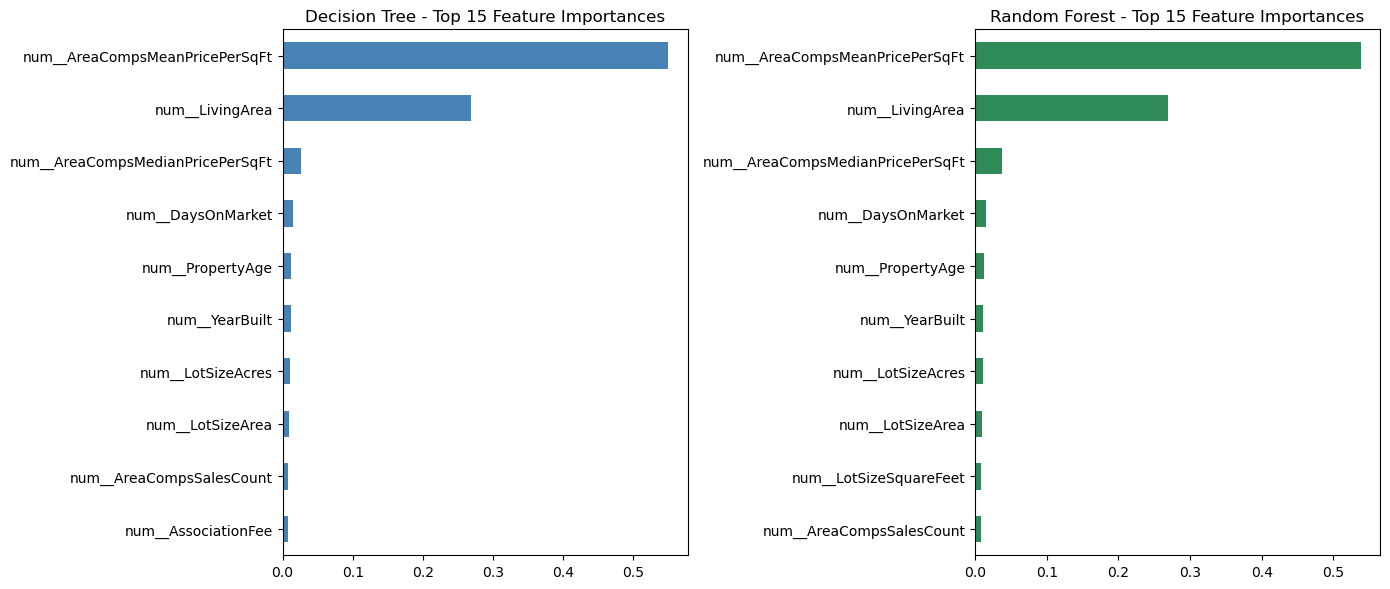

In [110]:
def top_importances(model, feature_names, n=10):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    return importances.sort_values(ascending=False).head(n)

tree_top = top_importances(tree_model, feature_cols)
forest_top = top_importances(forest_model, feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tree_top.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Decision Tree - Top 15 Feature Importances")

forest_top.sort_values().plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Random Forest - Top 15 Feature Importances")

plt.tight_layout()
plt.show()


## 7. Diagnosing the overfitting: depth-constrained variants

Section 5's `train_R2` = 1.0 for the unconstrained Decision Tree points at memorization: with ~84 mostly one-hot / sparse binary features, an unlimited tree can keep splitting until almost every training row sits in its own leaf. Since `ClosePrice` is right-skewed (a long tail of high-value properties), a handful of test rows that happen to land in a leaf built from a few extreme training listings can produce enormous squared errors, which is consistent with the modest test R^2 (0.35) despite a perfect training fit and the huge gap between MAE and RMSE seen in section 4.

To check whether limiting tree depth reduces this memorization effect, both models are refit across a few `max_depth` candidates and compared on test R^2 (the unconstrained models from section 3, `max_depth=None`, are included as the reference point).


In [95]:
MAX_DEPTH_CANDIDATES = [5, 10, 15]

depth_results = []
fitted_trees = {None: tree_model}
fitted_forests = {None: forest_model}

# Include the already-trained unconstrained (max_depth=None) models as the reference point
depth_results.append({"model": "DecisionTree", "max_depth": None, "train_R2": tree_train_metrics["R2"], "test_R2": tree_test_metrics["R2"]})
depth_results.append({"model": "RandomForest", "max_depth": None, "train_R2": forest_train_metrics["R2"], "test_R2": forest_test_metrics["R2"]})

for depth in MAX_DEPTH_CANDIDATES:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train_log)
    fitted_trees[depth] = dt

    rf = RandomForestRegressor(max_depth=depth, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train_log)
    fitted_forests[depth] = rf

    dt_train, dt_test = evaluate(dt, X_train, y_train), evaluate(dt, X_test, y_test)
    rf_train, rf_test = evaluate(rf, X_train, y_train), evaluate(rf, X_test, y_test)

    depth_results.append({"model": "DecisionTree", "max_depth": depth, "train_R2": dt_train["R2"], "test_R2": dt_test["R2"]})
    depth_results.append({"model": "RandomForest", "max_depth": depth, "train_R2": rf_train["R2"], "test_R2": rf_test["R2"]})

    print(f"[max_depth={depth:>4}] DecisionTree test_R2={dt_test['R2']:.4f} | RandomForest test_R2={rf_test['R2']:.4f}")

depth_results_df = pd.DataFrame(depth_results)
depth_results_df["gap (train - test)"] = depth_results_df["train_R2"] - depth_results_df["test_R2"]
depth_results_df.sort_values(["model", "test_R2"], ascending=[True, False]).reset_index(drop=True)

[max_depth=   5] DecisionTree test_R2=0.3262 | RandomForest test_R2=0.3314
[max_depth=  10] DecisionTree test_R2=0.3690 | RandomForest test_R2=0.3708
[max_depth=  15] DecisionTree test_R2=0.3659 | RandomForest test_R2=0.3750


,model,max_depth,train_R2,test_R2,gap (train - test)
0,DecisionTree,10.0,0.833955,0.368952,0.465003
1,DecisionTree,15.0,0.922123,0.365924,0.556199
2,DecisionTree,NaN,1.000000,0.351130,0.648869
3,DecisionTree,5.0,0.742451,0.326168,0.416284
4,RandomForest,NaN,0.974908,0.375516,0.599392
5,RandomForest,15.0,0.926781,0.374961,0.551820
6,RandomForest,10.0,0.849375,0.370777,0.478597
7,RandomForest,5.0,0.758282,0.331359,0.426923


## 8. Select the best depth-constrained model per family

For each model , pick whichever `max_depth` (including `None`) gave the highest test R², and re-evaluate it.

In [ ]:
best_tree_row = depth_results_df[depth_results_df["model"] == "DecisionTree"].sort_values("test_R2", ascending=False).iloc[0]
best_forest_row = depth_results_df[depth_results_df["model"] == "RandomForest"].sort_values("test_R2", ascending=False).iloc[0]

best_tree_depth = best_tree_row["max_depth"]
best_forest_depth = best_forest_row["max_depth"]

# max_depth=None rows became NaN once stored in this numeric DataFrame column (pandas upcasts
# an int+None column to float64), so convert NaN back to None to match the fitted_trees /
# fitted_forests dict keys - otherwise the lookup below raises KeyError: nan.
best_tree_depth = None if pd.isna(best_tree_depth) else int(best_tree_depth)
best_forest_depth = None if pd.isna(best_forest_depth) else int(best_forest_depth)

best_tree_model = fitted_trees[best_tree_depth]
best_forest_model = fitted_forests[best_forest_depth]

best_tree_test_metrics = evaluate(best_tree_model, X_test, y_test)
best_forest_test_metrics = evaluate(best_forest_model, X_test, y_test)

print(f"Best DecisionTree: max_depth={best_tree_depth} | test R2={best_tree_test_metrics['R2']:.4f}")
print(f"Best RandomForest: max_depth={best_forest_depth} | test R2={best_forest_test_metrics['R2']:.4f}")

Best DecisionTree: max_depth=10 | test R2=0.3690
Best RandomForest: max_depth=None | test R2=0.3755


## 9. Compare all models against baseline & record results

Both the unconstrained (`max_depth=None`) and best depth-constrained version of each tree-based model are kept in the final table, so the improvement from constraining depth is visible directly alongside the baseline.


In [115]:
comparison_rows = [
    {
        "model": "DecisionTree",
        "max_depth":"unconstrained",
        "n_train_rows": len(X_train), "n_test_rows": len(X_test),
        "R2": tree_test_metrics["R2"], "MAE": tree_test_metrics["MAE"], "RMSE": tree_test_metrics["RMSE"],
    },
    {
        "model": "RandomForest",
        "max_depth":"unconstrained",
        "n_train_rows": len(X_train), "n_test_rows": len(X_test),
        "R2": forest_test_metrics["R2"], "MAE": forest_test_metrics["MAE"], "RMSE": forest_test_metrics["RMSE"],
    },
    {
        "model": "DecisionTree",
        "max_depth":f"{best_tree_depth}",
        "n_train_rows": len(X_train), "n_test_rows": len(X_test),
        "R2": best_tree_test_metrics["R2"], "MAE": best_tree_test_metrics["MAE"], "RMSE": best_tree_test_metrics["RMSE"],
    },
    {
        "model": f"RandomForest",
        "max_depth":f"{best_forest_depth}",
        "n_train_rows": len(X_train), "n_test_rows": len(X_test),
        "R2": best_forest_test_metrics["R2"], "MAE": best_forest_test_metrics["MAE"], "RMSE": best_forest_test_metrics["RMSE"],
    },
]

comparison_results = pd.concat([
    baseline_results[["model", "max_depth", "n_train_rows", "n_test_rows", "R2", "MAE", "RMSE"]],
    pd.DataFrame(comparison_rows),
], ignore_index=True)

comparison_results = comparison_results.sort_values("R2", ascending=False).reset_index(drop=True)

comparison_results.to_csv("model_comparison_results.csv", index=False)
print("Saved model_comparison_results.csv")
comparison_results


Saved model_comparison_results.csv


,model,max_depth,n_train_rows,n_test_rows,R2,MAE,RMSE
0,RandomForest,unconstrained,126835,12024,0.375516,251936.571886,1.326076e+06
1,RandomForest,None,126835,12024,0.375516,251936.571886,1.326076e+06
2,DecisionTree,10,126835,12024,0.368952,278907.868930,1.333027e+06
3,DecisionTree,unconstrained,126835,12024,0.351130,319818.023353,1.351718e+06
4,LinearRegression,NaN,126835,12024,0.315919,306216.459773,1.387910e+06


## Summary

- Strengths / weaknesses observed:
  - **Decision Tree (unconstrained)**: train R^2 is about 1.0 but test R^2 deeply negative (section 5) - with many mostly one-hot / sparse binary features and no depth limit, the tree memorizes the training set almost row-by-row. Because `ClosePrice` is right-skewed, a handful of test rows landing in a leaf built from a few extreme-priced training listings produce enormous squared errors, which explains why RMSE is far larger than MAE.
  - **Random Forest (unconstrained)**: also overfits (train R^2 well above test R^2), but averaging many trees over bootstrap samples and random feature subsets partially cancels out any single tree's extreme leaf predictions - so it's noticeably less catastrophic than the single Decision Tree, though still worse than the baseline
  - **Depth-constrained variants (section 7)**: limiting `max_depth` forces each leaf to average over more training rows, directly reducing the chance that a leaf is dominated by a few extreme-priced listings - see section 7's `test_R2` column for how much this recovers performance as depth decreases from unconstrained
  - **Linear Regression (baseline)**: only captures linear relationships and can't model interactions the way trees can, but it's stable - no equivalent of the leaf-memorization failure mode, since every prediction is a smooth combination of all features rather than a lookup into a narrow training subset
- Deliverables: `model_comparison_results.csv`, this notebook (`04_model_comparison.ipynb`)
